In [31]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

- https://github.com/OMS-NetZero/FAIR/blob/master/src/fair/gas_cycle/eesc.py
- https://github.com/OMS-NetZero/FAIR/blob/master/src/fair/forcing/ozone.py

In [32]:
f = FAIR(ch4_method="Thornhill2021")
f.define_time(1750, 2300, 1)  # start, end, step

"""
scenarios = [
    "high-extension",
    "high-overshoot",
    "medium-overshoot",
    "medium-extension",
    "low",
    "verylow",
    "verylow-overshoot",
]
"""

scenarios_Rcimp = ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp534-over', 'ssp585']
f.define_scenarios(scenarios_Rcimp)
fair_params_1_4_1_file = 'examples/data/calibrated_constrained_ensemble/calibrated_constrained_parameters_calibration1.4.1.csv'
df_configs = pd.read_csv(fair_params_1_4_1_file, index_col=0)
configs = df_configs.index  # this is used as a label for the "config" axis
f.define_configs(configs)
fair_species_configs_1_4_1_file = 'examples/data/calibrated_constrained_ensemble/species_configs_properties_calibration1.4.1.csv'
species_Rcimp, properties = read_properties(filename=fair_species_configs_1_4_1_file)
f.define_species(species_Rcimp, properties)
f.allocate()
"""
f.fill_from_csv(
    emissions_file='examples/data/calibrated_constrained_ensemble/extensions_1750-2500.csv',
    forcing_file='examples/data/calibrated_constrained_ensemble/volcanic_solar.csv',
)
"""
f.fill_from_rcmip()

In [33]:
array = f.species
print(array)  # check if CO2 FFI is in the species list

['CO2 FFI', 'CO2 AFOLU', 'CO2', 'CH4', 'N2O', 'Sulfur', 'BC', 'OC', 'NH3', 'NOx', 'VOC', 'CO', 'CFC-11', 'CFC-12', 'CFC-113', 'CFC-114', 'CFC-115', 'HCFC-22', 'HCFC-141b', 'HCFC-142b', 'CCl4', 'CHCl3', 'CH2Cl2', 'CH3Cl', 'CH3CCl3', 'CH3Br', 'Halon-1211', 'Halon-1301', 'Halon-2402', 'CF4', 'C2F6', 'C3F8', 'c-C4F8', 'C4F10', 'C5F12', 'C6F14', 'C7F16', 'C8F18', 'NF3', 'SF6', 'SO2F2', 'HFC-125', 'HFC-134a', 'HFC-143a', 'HFC-152a', 'HFC-227ea', 'HFC-23', 'HFC-236fa', 'HFC-245fa', 'HFC-32', 'HFC-365mfc', 'HFC-4310mee', 'Solar', 'Volcanic', 'Aerosol-radiation interactions', 'Aerosol-cloud interactions', 'Ozone', 'Light absorbing particles on snow and ice', 'Stratospheric water vapour', 'Land use', 'Equivalent effective stratospheric chlorine']


# Check Remove Number

In [34]:
def remove_species(model, ranked_species_array, top_n = 10):
    top_species = set(ranked_species_array[:top_n])
    print(top_species)
    total_specie = model.species
    for specie in total_specie:
        if specie not in top_species:
            init_emissions = model.emissions.isel(timepoints=0).sel(specie=specie)[0][0].values
            model.emissions.loc[dict(specie = specie)] = init_emissions

ranked_species_rcimp = []
with open ('TOP_species_rcimp_modified.txt', 'r') as file:
    for line in file:
        ranked_species_rcimp.append(line.strip())
remove_species(f, ranked_species_rcimp, 12)

{'N2O', 'NOx', 'CO2 FFI', 'CFC-12', 'BC', 'CO2 AFOLU', 'OC', 'Sulfur', 'HFC-143a', 'CH4', 'HFC-125', 'CFC-11'}


In [35]:
f.forcing.sel(specie="Volcanic")
fill(
    f.forcing,
    f.forcing.sel(specie="Volcanic") * df_configs["forcing_scale[Volcanic]"].values.squeeze(),
    specie="Volcanic",
)
fill(
    f.forcing,
    f.forcing.sel(specie="Solar") * df_configs["forcing_scale[Solar]"].values.squeeze(),
    specie="Solar",
)
f.fill_species_configs(fair_species_configs_1_4_1_file)
f.override_defaults(fair_params_1_4_1_file)
initialise(f.concentration, f.species_configs["baseline_concentration"])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)
initialise(f.ocean_heat_content_change, 0)

In [36]:
f.run()

Running 6728 projections in parallel:   0%|          | 0/550 [00:00<?, ?timesteps/s]

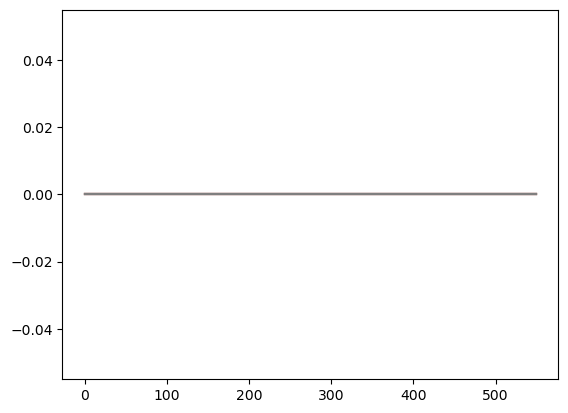

In [37]:
pl.plot(f.emissions.sel(specie = "NF3", config = 1234))

In [38]:
fancy_titles = {
    'ssp119': 'ssp119',
    'ssp126': 'ssp126',
    'ssp245': 'ssp245',
    'ssp370': 'ssp370',
    'ssp434': 'ssp434',
    'ssp460': 'ssp460',
    'ssp534-over': 'ssp534-over',
    'ssp585': 'ssp585'
}

colors = {
    'ssp119': '#0000FF',    # Dark blue for lowest emissions
    'ssp126': '#4169E1',    # Royal blue
    'ssp245': '#00BFFF',    # Deep sky blue
    'ssp370': '#FFD700',    # Gold
    'ssp434': '#FFA500',    # Orange
    'ssp460': '#FF4500',    # Orange red
    'ssp534-over': '#DC143C',    # Crimson
    'ssp585': '#8B0000'     # Dark red for highest emissions
}

weights_51yr = np.ones(52)
weights_51yr[0] = 0.5
weights_51yr[-1] = 0.5

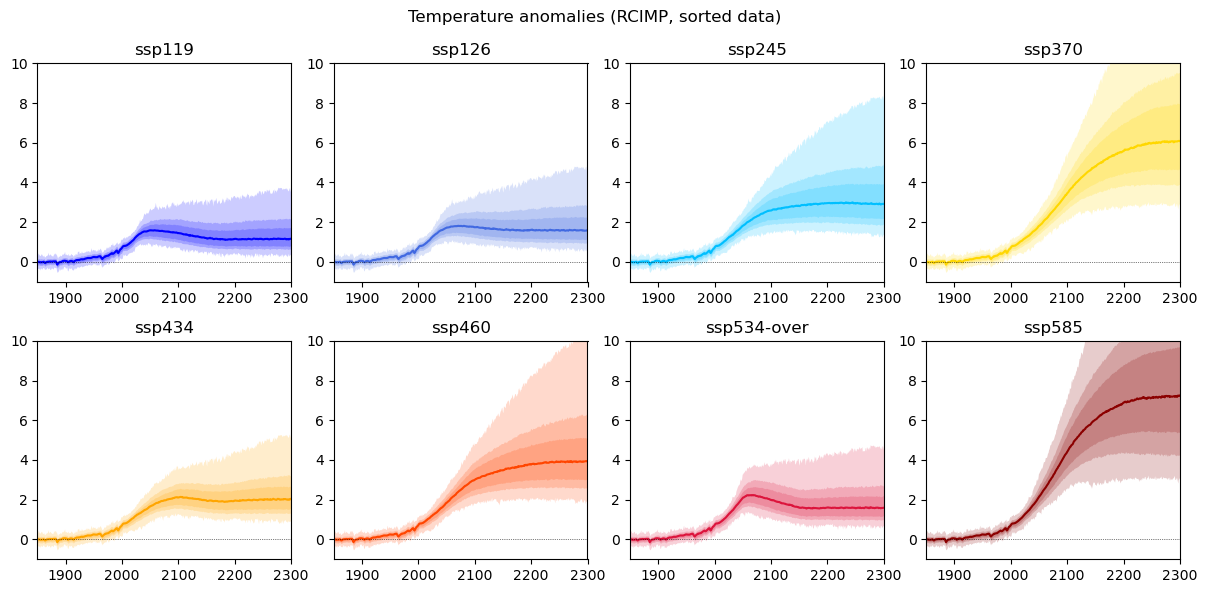

In [39]:
fig, ax = pl.subplots(2, 4, figsize=(12, 6))

for i, scenario in enumerate(f.scenarios):
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f.timebounds,
            np.percentile(
                f.temperature.loc[dict(scenario=scenario, layer=0)]
                - np.average(
                    f.temperature.loc[
                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                    ],
                    weights=weights_51yr,
                    axis=0
                ),
                pp[0],
                axis=1,
            ),
            np.percentile(
                f.temperature.loc[dict(scenario=scenario, layer=0)]
                - np.average(
                    f.temperature.loc[
                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                    ],
                    weights=weights_51yr,
                    axis=0
                ),
                pp[1],
                axis=1,
            ),
            color=colors[f.scenarios[i]],
            alpha=0.2,
            lw=0
        )

    ax[i // 4, i % 4].plot(
        f.timebounds,
        np.median(
            f.temperature.loc[dict(scenario=scenario, layer=0)]
            - np.average(
                f.temperature.loc[
                    dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                ],
                weights=weights_51yr,
                axis=0
            ),
            axis=1,
        ),
        color=colors[f.scenarios[i]],
    )
    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].set_ylim(-1, 10)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[f.scenarios[i]])

pl.suptitle("Temperature anomalies (RCIMP, sorted data)")
fig.tight_layout()

# Check File Name

In [40]:
# save fair object
import pickle

with open("/glade/work/stevenxu/FAIR_models/top12_model.pkl", "wb") as f_out:
    pickle.dump(f, f_out)


TODO: 
- Compare by subtracitng to the origional model